## Import & Load
  

In [11]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from diasense.config import  (CLINICAL_FEATURES,RAW_DATA_FILE,ZERO_AS_MISSING,REPORTS_DIR,FIGURES_DIR)
from diasense.data import load_raw_data,validate_columns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

df = load_raw_data()
validate_columns(df)

print("data load successfully")
print(df.shape)



data load successfully
(768, 8)


## General structure of the dataset

In [2]:
print("=========== Dimensions: ===========")
print(df.shape)

print("=========== Data Type =================")
print(df.dtypes)

print("=========== Info =====================")
print(df.info(memory_usage="deep"))



=========== Dimensions: ===========
(768, 8)
=========== Data Type =================
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object
=========== Info =====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction 

In [3]:
print("=========== First Rows =====================")
display(df.head())
print("===================== Last 5 rows =====================")
display(df.tail())

print("===================== Discribe =====================")
display(df.describe().round(2))


=========== First Rows =====================


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


===================== Last 5 rows =====================


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47
767,1,93,70,31,0,30.4,0.315,23


===================== Discribe =====================


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00


**Key observations from `describe`:**

- All 8 columns are numeric (int64 or float64).
- Some columns show minimum = 0 where that is clinically impossible:
  - `Glucose` min = 0 so no patient has glucose 0
  - `BloodPressure` min = 0
  - `SkinThickness` min = 0
  - `Insulin` min = 0
  - `BMI` min = 0.0
- These zeros are **hidden missing values**, not real measurements.

## Missing values & duplicates and hidden zeros


There are **no NaN** in this dataset. The missing information is encoded as **0** in columns where 0 is physiologically impossible.

In [4]:
nan_reports = df.isna().sum()

print("============ NaN per Column =======")
print(nan_reports)
print("============ total NaN =======")
print(nan_reports.sum())

============ NaN per Column =======
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
============ total NaN =======
0


In [12]:
# check duplicate 
n_duplicates = df.duplicated().sum()
print("n_duplicates: ",n_duplicates)

n_duplicates:  0


In [6]:
# Hidden Zeros
zeros = 0
total_rows = len(df)

print("count of zeros")
print(f"{'Column':<30} {'zeros':>8} {'%total':>12}")



for col in ZERO_AS_MISSING:
    zeros = int((df[col] == 0).sum()) 
    pct = zeros/total_rows *100
    print(f"{col:<30} {zeros:>8} {pct:>11.1f}%")


print(zeros)


count of zeros
Column                            zeros       %total
Glucose                               5         0.7%
BloodPressure                        35         4.6%
SkinThickness                       227        29.6%
Insulin                             374        48.7%
BMI                                  11         1.4%
11


## Zero heatmap

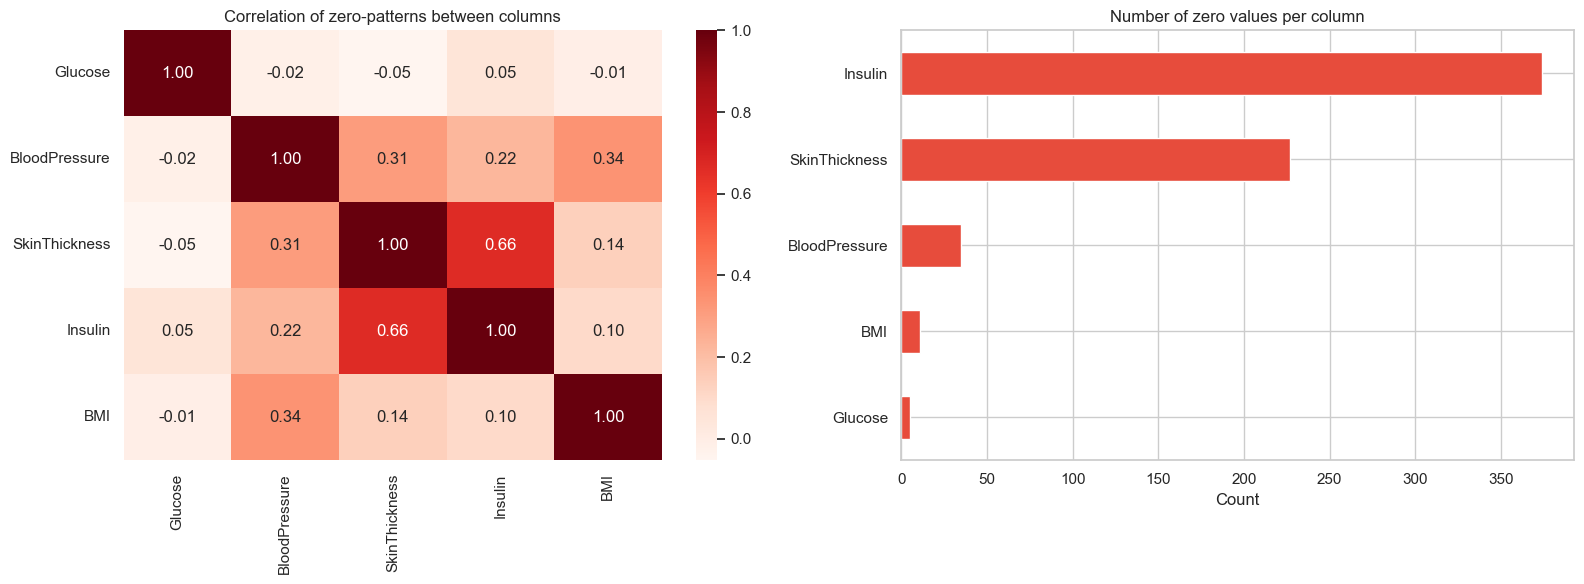

In [13]:
zero_mask = df[ZERO_AS_MISSING] == 0

fig,axes = plt.subplots(1,2,figsize = (16,6))

sns.heatmap(
    zero_mask.corr(),
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[0],

)
axes[0].set_title("Correlation of zero-patterns between columns")

# Bar chart
zero_counts = zero_mask.sum().sort_values(ascending=True)
zero_counts.plot.barh(ax=axes[1], color="#e74c3c")
axes[1].set_title("Number of zero values per column")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig( FIGURES_DIR / "eda_zero_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


##  Distribution of numerical variables
We analyze the shape, central tendency and spread of each clinical feature using histograms, boxplots, skewness and kurtosis.

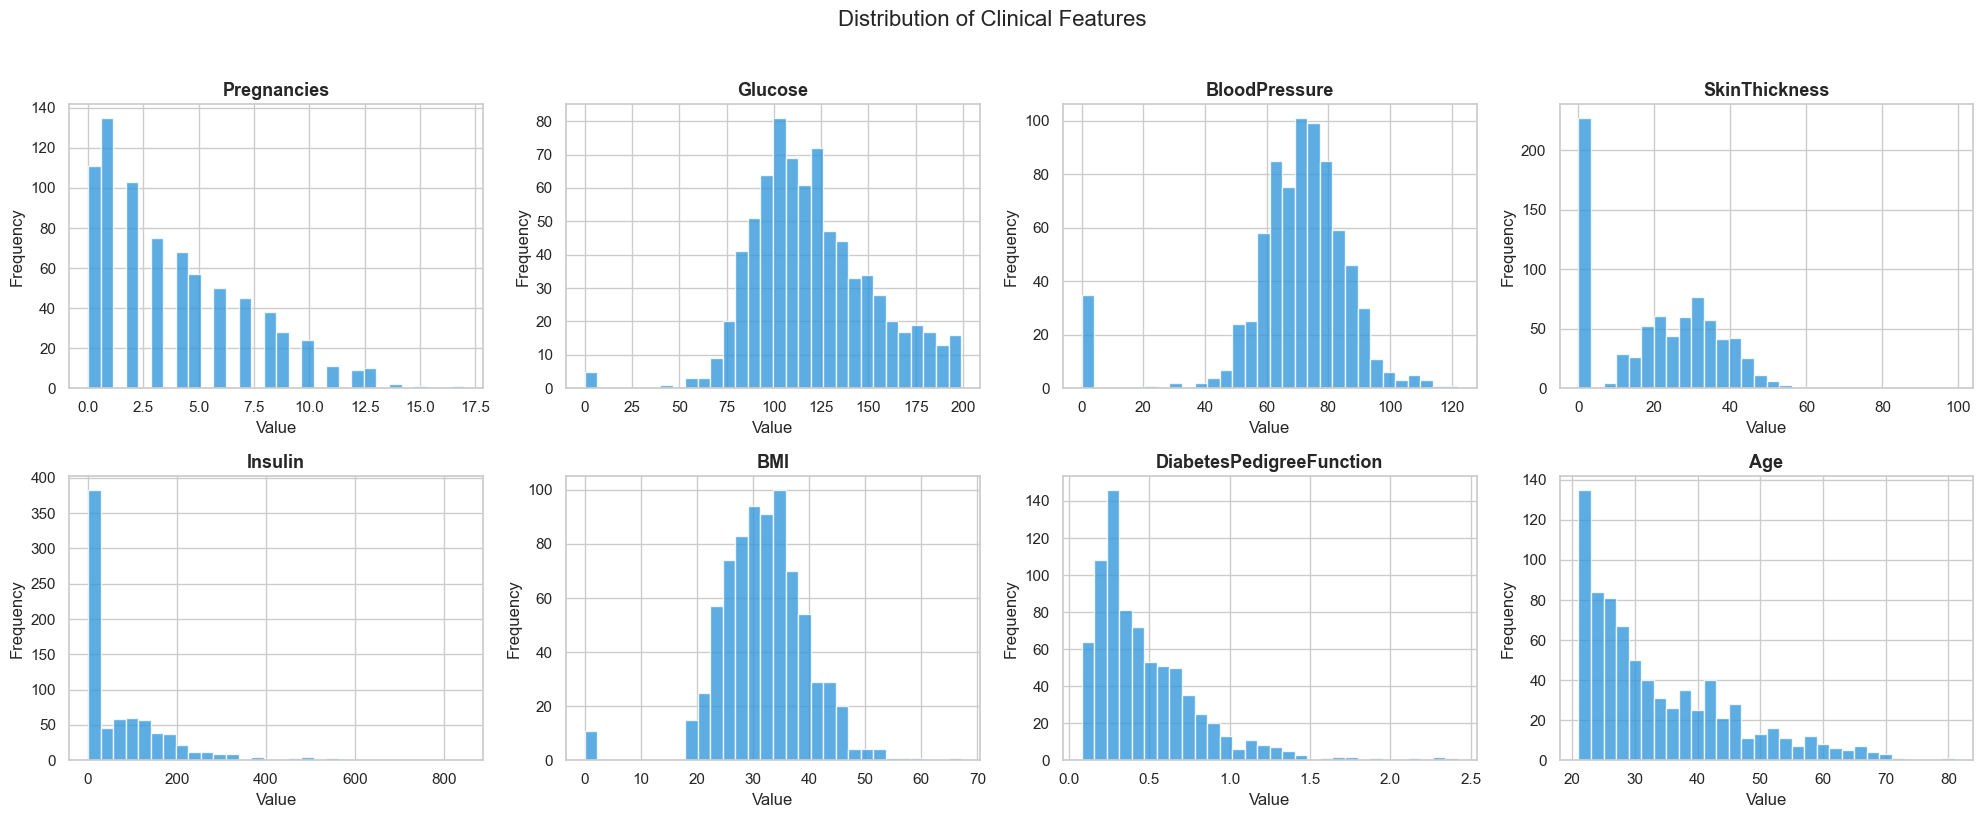

In [15]:
# Histograms for all features (histogram for every clinic feature )


n_features = len(CLINICAL_FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CLINICAL_FEATURES):
    axes[i].hist(df[col], bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused axes if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Clinical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig( FIGURES_DIR / "eda_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

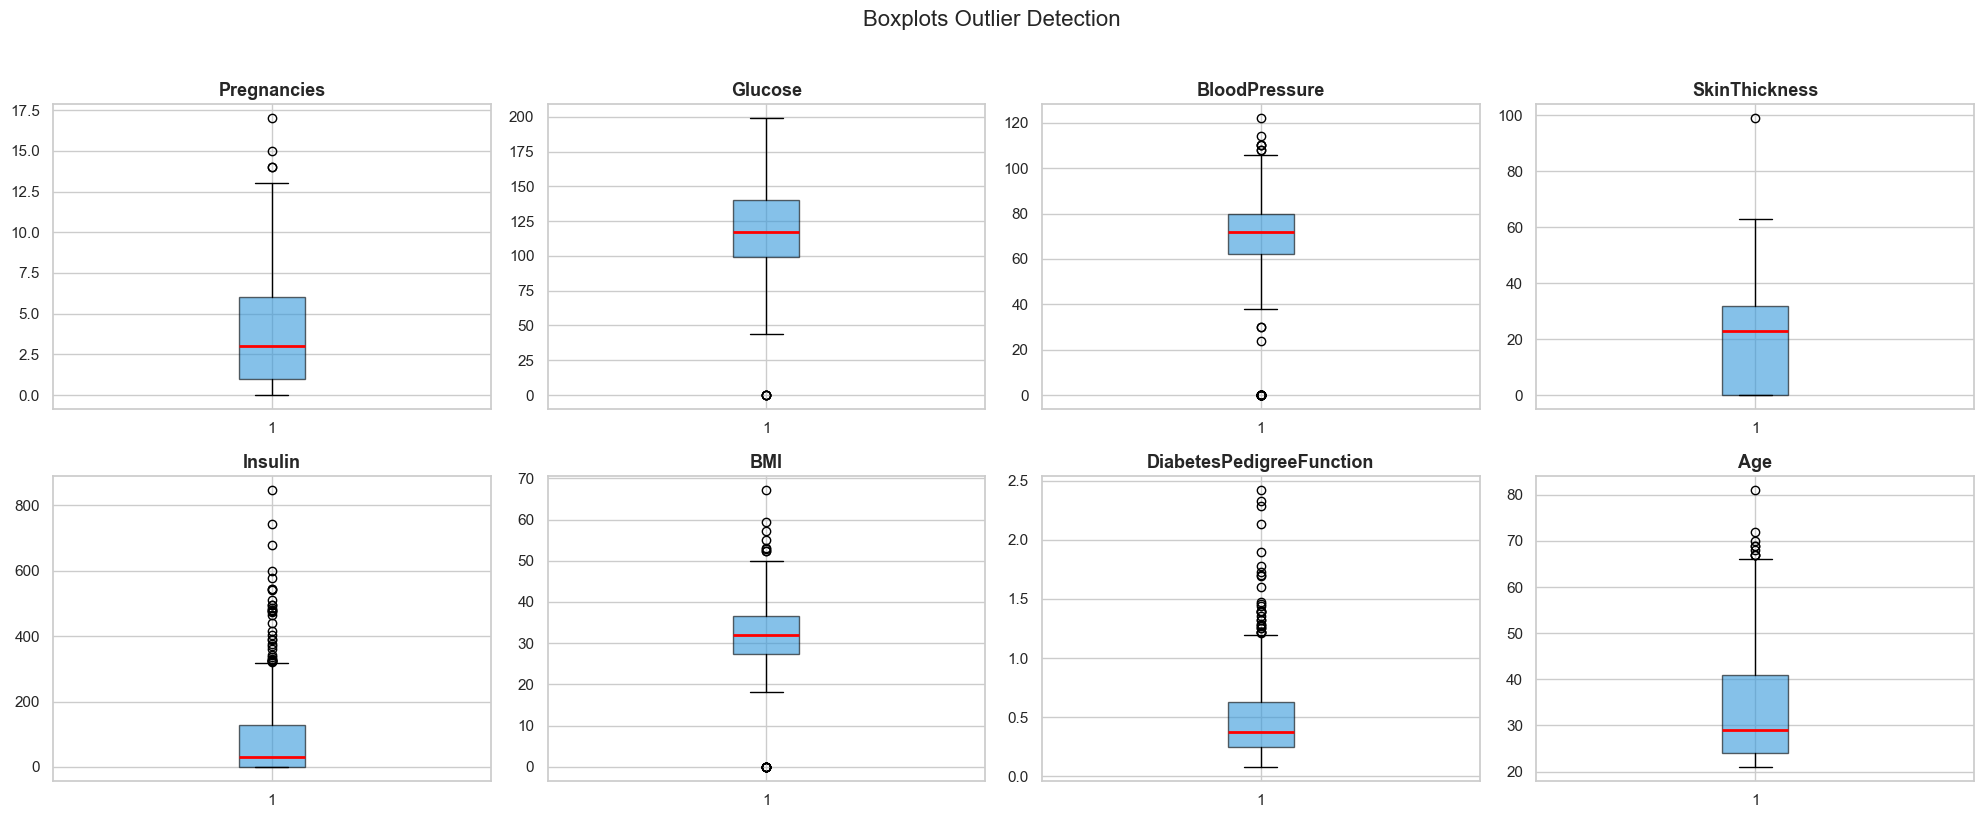

In [16]:
# Boxplots to spot outliers 
fig,axes = plt.subplots(n_rows,n_cols,figsize = (20,4*n_rows))
axes = axes.flatten()


for i, col in enumerate(CLINICAL_FEATURES):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.6),
                    medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(col, fontsize=13, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots Outlier Detection", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
## skewness and kurtosis
stats_df = pd.DataFrame({
    "Column": CLINICAL_FEATURES,
    "Skewness": [df[c].skew() for c in CLINICAL_FEATURES],
    "Kurtosis": [df[c].kurtosis() for c in CLINICAL_FEATURES],
    "Mean": [df[c].mean() for c in CLINICAL_FEATURES],
    "Median": [df[c].median() for c in CLINICAL_FEATURES],
    "Std": [df[c].std() for c in CLINICAL_FEATURES],
    "Min": [df[c].min() for c in CLINICAL_FEATURES],
    "Max": [df[c].max() for c in CLINICAL_FEATURES],
}).round(2)

display(stats_df)

,Column,Skewness,Kurtosis,Mean,Median,Std,Min,Max
0,Pregnancies,0.90,0.16,3.85,3.00,3.37,0.00,17.00
1,Glucose,0.17,0.64,120.89,117.00,31.97,0.00,199.00
2,BloodPressure,-1.84,5.18,69.11,72.00,19.36,0.00,122.00
3,SkinThickness,0.11,-0.52,20.54,23.00,15.95,0.00,99.00
4,Insulin,2.27,7.21,79.80,30.50,115.24,0.00,846.00
5,BMI,-0.43,3.29,31.99,32.00,7.88,0.00,67.10
6,DiabetesPedigreeFunction,1.92,5.59,0.47,0.37,0.33,0.08,2.42
7,Age,1.13,0.64,33.24,29.00,11.76,21.00,81.00


## pairplot on a subset

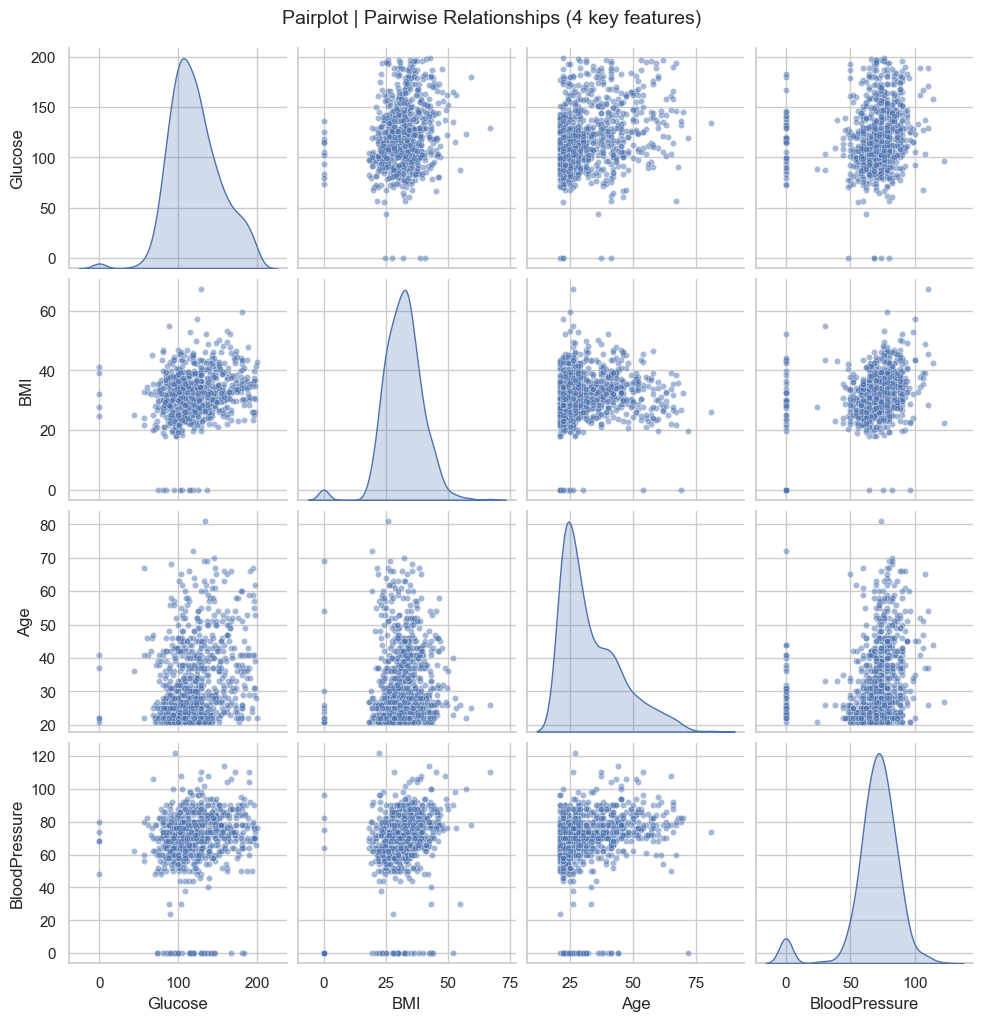

In [ ]:
# 4 features 
pair_features = ["Glucose", "BMI", "Age", "BloodPressure"]

sns.pairplot(
    df[pair_features],
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20, "edgecolor": "white"},
    height=2.5,
)
plt.suptitle("Pairplot | Pairwise Relationships (4 key features)", y=1.02, fontsize=14)
plt.savefig(REPORTS_DIR / "eda_pairplot_subset.png", dpi=150, bbox_inches="tight")
plt.show()

## correlation heatmap

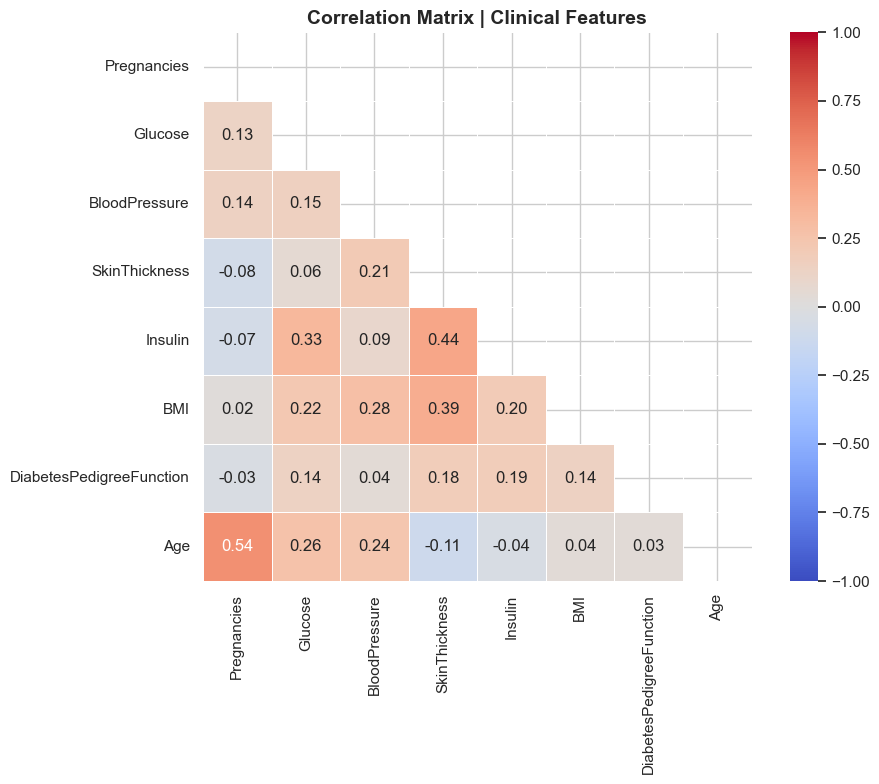

In [18]:

corr = df[CLINICAL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix | Clinical Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()